In [41]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
import urllib
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [42]:
def load_image_from_url(url):
    try:
        with urllib.request.urlopen(url) as response:
            img_array = np.asarray(bytearray(response.read()), dtype=np.uint8)
            return cv.imdecode(img_array, cv.IMREAD_COLOR)
    except Exception as e:
        print(f"Erro no URL {url}: {e}")
        return None

image_urls = [
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/01.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/02.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/03.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/04.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/05.jpg",
    "https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/06.jpg"
]

In [ ]:
def foreground_background(left_url, right_url, numDisparities=64, blockSize=5, threshold=110):
    """
    Gera efeito de modo retrato a partir de um par de imagens estéreo.
    
    Args:
        left_url, right_url: URLs das imagens esquerda e direita
        numDisparities: Número de disparidades no algoritmo StereoBM
        blockSize: Tamanho do bloco de correspondência
        threshold: Limiar para segmentação de foreground/background
    
    Returns:
        original: Imagem original (esquerda)
        disparity_visual: Mapa de disparidade normalizado para visualização
        fg_mask: Máscara do foreground
        result: Imagem com efeito de modo retrato
    """
    # Carregar as imagens
    left_img = load_image_from_url(left_url)
    right_img = load_image_from_url(right_url)
    
    # Converter para escala de cinza
    gray_left = cv.cvtColor(left_img, cv.COLOR_BGR2GRAY)
    gray_right = cv.cvtColor(right_img, cv.COLOR_BGR2GRAY)
    
    # Configurar o algoritmo StereoBM
    stereo = cv.StereoBM.create(numDisparities=numDisparities, blockSize=blockSize)
    
    # Parâmetros opcionais para melhorar a qualidade
    stereo.setTextureThreshold(20)
    stereo.setUniquenessRatio(15)
    stereo.setSpeckleRange(16)
    # stereo.setSpeckleWindowSize(100)
    stereo.setDisp12MaxDiff(25)
    
    # Calcular o mapa de disparidade
    disparity = stereo.compute(gray_left, gray_right)
    
    # Normalizar para visualização (0-255)
    disparity_visual = cv.normalize(disparity, None, alpha=0, beta=255, norm_type=cv.NORM_MINMAX, dtype=cv.CV_8U)
    
    # Inverter para que objetos próximos sejam claros (para melhor visualização)
    # disparity_visual = cv.bitwise_not(disparity_visual)
    
    # Criar máscara para o foreground (objetos próximos têm maior disparidade)
    _, fg_mask = cv.threshold(disparity_visual, threshold, 255, cv.THRESH_BINARY)
    
    # Aplicar operações morfológicas para melhorar a máscara
    kernel = np.ones((5, 5), np.uint8)
    fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_CLOSE, kernel)
    fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_OPEN, kernel)
    
    # Desfoque gaussiano para o background
    blurred = cv.GaussianBlur(left_img, (25, 25), 0)
    
    # Extrair foreground e background
    foreground = cv.bitwise_and(left_img, left_img, mask=fg_mask)
    bg_mask = cv.bitwise_not(fg_mask)
    background = cv.bitwise_and(blurred, blurred, mask=bg_mask)
    
    # Combinar foreground nítido com background desfocado
    result = cv.add(foreground, background)
    
    return left_img, disparity_visual, fg_mask, result

Processando par 01-02...


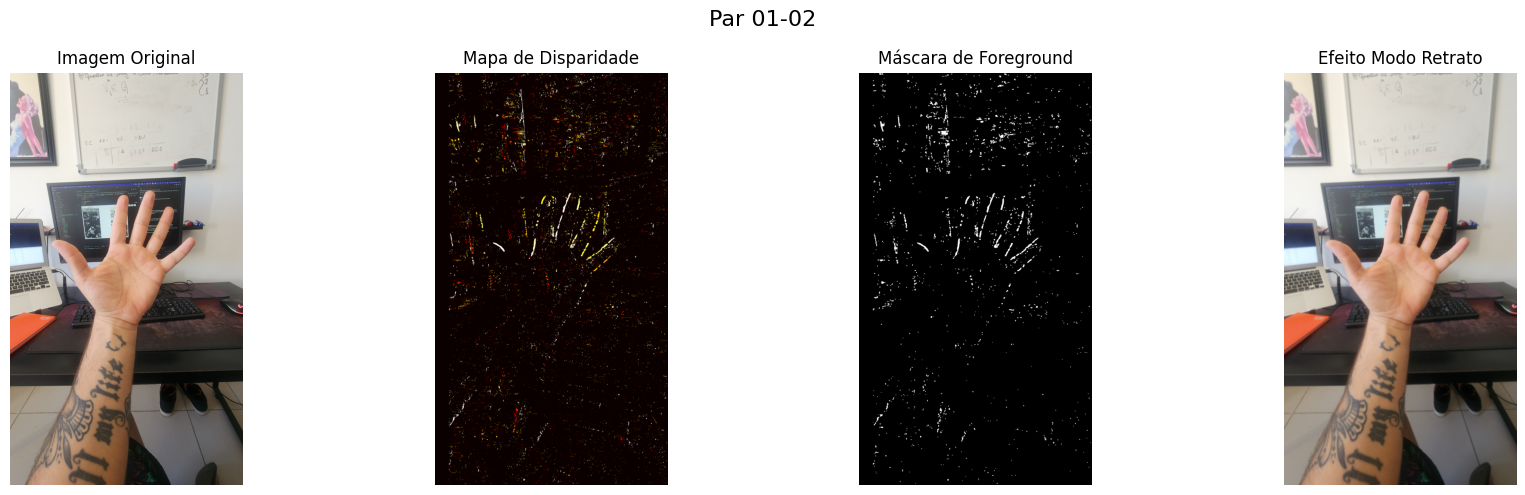

Processando par 03-04...


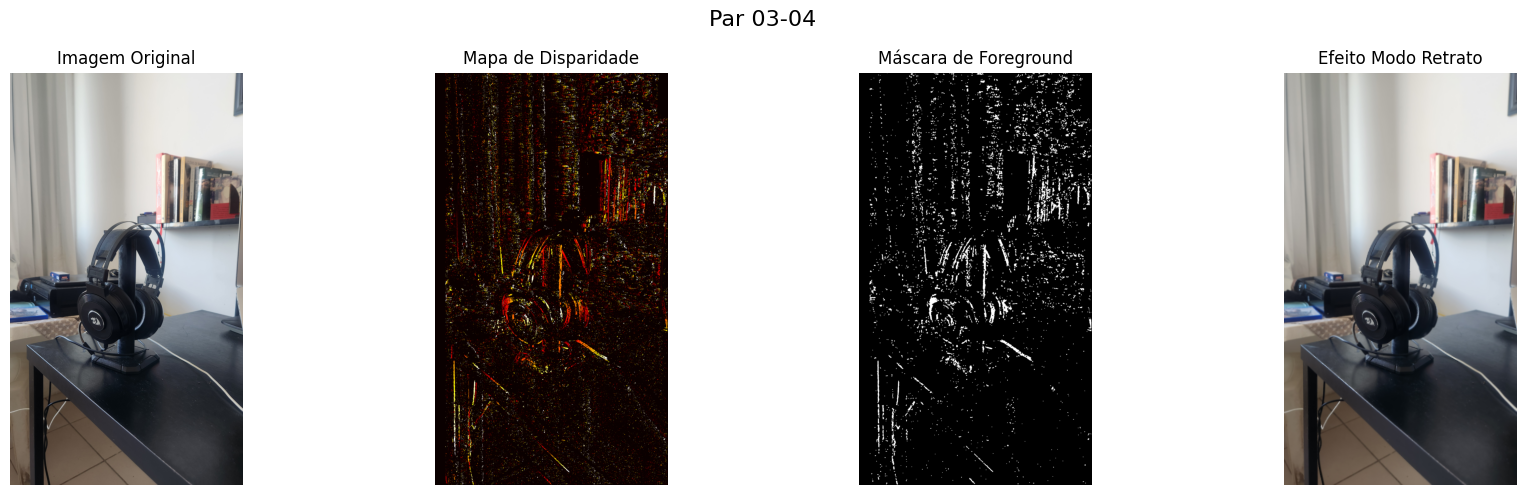

Processando par 05-06...
Erro no URL https://raw.githubusercontent.com/Delevati/vc-2024-2/main/img/task04/06.jpg: HTTP Error 429: Too Many Requests


error: OpenCV(4.11.0) /private/var/folders/zb/fsvx994s2g54rx2zz2nh6sp40000gn/T/pip-install-1kisax0g/opencv-python_73e27ae3737a46c3853d2d66fa1bf6ce/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [44]:
def process_pair():
    pairs = []
    for i in range(0, len(image_urls), 2):
        if i+1 < len(image_urls):
            left_url = image_urls[i]
            right_url = image_urls[i+1]
            left_name = left_url.split('/')[-1].split('.')[0]
            right_name = right_url.split('/')[-1].split('.')[0]
            pairs.append({
                'name': f"{left_name}-{right_name}",
                'left_url': left_url,
                'right_url': right_url
            })
    
    params = [
        {'numDisparities': 128, 'blockSize': 15, 'threshold': 50},  # 01-02
        {'numDisparities': 96, 'blockSize': 11, 'threshold': 80},   # 03-04
        {'numDisparities': 64, 'blockSize': 13, 'threshold': 60}    # 05-06
    ]
    
    # Processar cada par
    for i, pair in enumerate(pairs):
        print(f"Processando par {pair['name']}...")
        
        original, disparity, mask, portrait = foreground_background(
            pair['left_url'], 
            pair['right_url'],
            **params[i]
        )

        plt.figure(figsize=(18, 5))
        
        plt.subplot(1, 4, 1)
        plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
        plt.title('Imagem Original')
        plt.axis('off')
        
        plt.subplot(1, 4, 2)
        plt.imshow(disparity, cmap='hot')
        plt.title('Mapa de Disparidade')
        plt.axis('off')
        
        plt.subplot(1, 4, 3)
        plt.imshow(mask, cmap='gray')
        plt.title('Máscara de Foreground')
        plt.axis('off')
        
        plt.subplot(1, 4, 4)
        plt.imshow(cv.cvtColor(portrait, cv.COLOR_BGR2RGB))
        plt.title('Efeito Modo Retrato')
        plt.axis('off')
        
        plt.suptitle(f'Par {pair["name"]}', fontsize=16)
        plt.tight_layout()
        plt.show()

process_pair()